# Assignment 5 — Notebook 02: Tải, Khảo Sát & Tăng Cường Dữ Liệu (NEW DATASETS)

**Mục tiêu bài thực hành:**
1. Chuẩn bị 2 tập dữ liệu hình ảnh hoàn toàn mới:
   - **Fashion-MNIST**: 70.000 ảnh sản phẩm thời trang Zalando ($28 \times 28 \times 1$).
   - **SVHN (Street View House Numbers)**: 99.289 ảnh màu $32 \times 32 \times 3$ số nhà ngoài đời thực từ Google Street View.
2. Khảo sát dữ liệu y tế cộng đồng **CDC Diabetes Health Indicators** (253.680 dòng).
3. Áp dụng kỹ thuật **Tăng cường dữ liệu (Data Augmentation)** để mở rộng tập Diabetes lên **513.703 dòng**, giải quyết triệt để mất cân bằng lớp.
4. Đóng gói tệp `.npz` đồng bộ để Keras và PyTorch dùng chung 100% dữ liệu chia train/val/test.

In [1]:
# Cell 1: Khai báo thư viện và cấu hình môi trường
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('Môi trường xử lý dữ liệu sẵn sàng.')

Môi trường xử lý dữ liệu sẵn sàng.


## 1. Tập dữ liệu ảnh số 1: Fashion-MNIST (70.000 ảnh sản phẩm thời trang 10 lớp)

In [2]:
# Cell 2: Nạp dữ liệu Fashion-MNIST
f_data = np.load('data/fashion_mnist/fashion_mnist_data.npz')
x_tr_f = f_data['x_train']
y_tr_f = f_data['y_train']
x_te_f = f_data['x_test']
y_te_f = f_data['y_test']

fashion_classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']
print(f'Fashion-MNIST Train shape: {x_tr_f.shape} | Test shape: {x_te_f.shape}')
print(f'10 Lớp thời trang: {fashion_classes}')

Fashion-MNIST Train shape: (60000, 28, 28) | Test shape: (10000, 28, 28)
10 Lớp thời trang: ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']


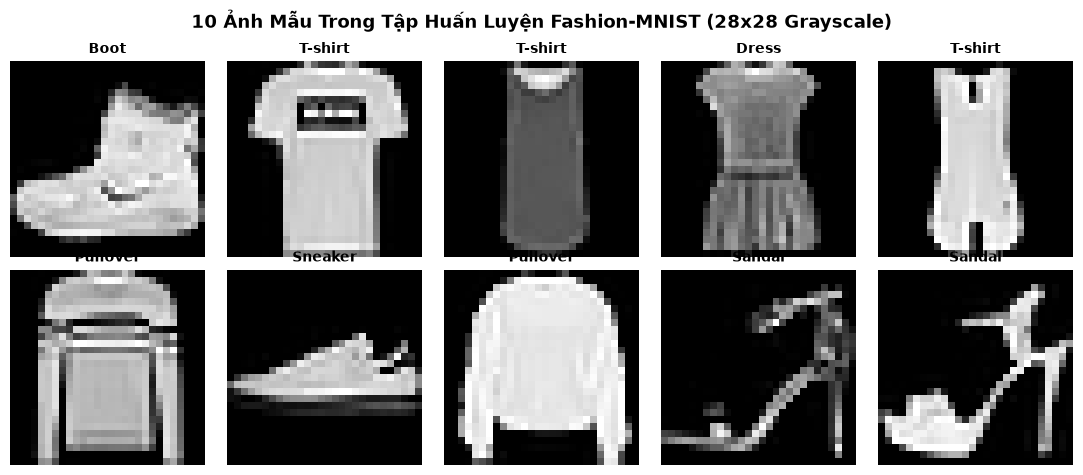

In [3]:
# Cell 3: Trực quan hóa 10 ảnh thời trang mẫu từ Fashion-MNIST
fig, axes = plt.subplots(2, 5, figsize=(11, 4.8))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_tr_f[i], cmap='gray')
    ax.set_title(fashion_classes[y_tr_f[i]], fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle('10 Ảnh Mẫu Trong Tập Huấn Luyện Fashion-MNIST (28x28 Grayscale)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Tập dữ liệu ảnh số 2: SVHN (Street View House Numbers — 99.289 ảnh màu Google Street View)

In [4]:
# Cell 4: Nạp dữ liệu SVHN
svhn_data = np.load('data/svhn/svhn_data.npz')
x_tr_s = svhn_data['x_train']
y_tr_s = svhn_data['y_train']
x_te_s = svhn_data['x_test']
y_te_s = svhn_data['y_test']

print(f'SVHN Train shape: {x_tr_s.shape} | Test shape: {x_te_s.shape}')
print(f'Kích thước mỗi ảnh: 32x32x3 RGB Color, tổng mẫu: {len(x_tr_s) + len(x_te_s):,}')

SVHN Train shape: (73257, 32, 32, 3) | Test shape: (26032, 32, 32, 3)
Kích thước mỗi ảnh: 32x32x3 RGB Color, tổng mẫu: 99,289


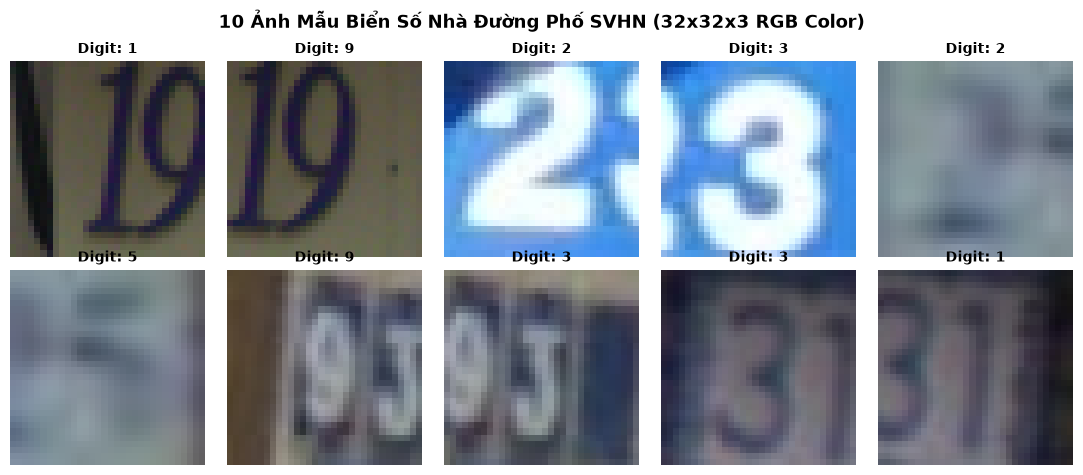

In [5]:
# Cell 5: Trực quan hóa 10 ảnh màu thực tế từ Google Street View
fig, axes = plt.subplots(2, 5, figsize=(11, 4.8))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_tr_s[i])
    ax.set_title(f'Digit: {y_tr_s[i]}', fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle('10 Ảnh Mẫu Biển Số Nhà Đường Phố SVHN (32x32x3 RGB Color)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Tập dữ liệu bảng lớn CDC Diabetes & Tăng Cường Dữ Liệu (>513.000 dòng)

In [6]:
# Cell 6: Khảo sát tập dữ liệu CDC Diabetes ban đầu
df_raw = pd.read_csv('data/diabetes/diabetes_raw.csv')
dist_raw = df_raw['Diabetes_012'].value_counts().to_dict()
print(f'Quy mô tập dữ liệu gốc: {len(df_raw):,} dòng x {df_raw.shape[1]} cột')
print('Phân phối nhãn ban đầu (Mất cân bằng 46 lần):')
print(f'  - Nhóm 0 (Khỏe mạnh):      {dist_raw.get(0.0, 0):,} ({dist_raw.get(0.0, 0)/len(df_raw)*100:.1f}%)')
print(f'  - Nhóm 1 (Tiền tiểu đường): {dist_raw.get(1.0, 0):,} ({dist_raw.get(1.0, 0)/len(df_raw)*100:.1f}%)')
print(f'  - Nhóm 2 (Tiểu đường):      {dist_raw.get(2.0, 0):,} ({dist_raw.get(2.0, 0)/len(df_raw)*100:.1f}%)')

Quy mô tập dữ liệu gốc: 253,680 dòng x 22 cột
Phân phối nhãn ban đầu (Mất cân bằng 46 lần):
  - Nhóm 0 (Khỏe mạnh):      213,703 (84.2%)
  - Nhóm 1 (Tiền tiểu đường): 4,631 (1.8%)
  - Nhóm 2 (Tiểu đường):      35,346 (13.9%)


In [7]:
# Cell 7: Kiểm tra kết quả tăng cường dữ liệu lên 513.703 dòng
df_aug = pd.read_csv('data/diabetes/diabetes_augmented.csv')
dist_aug = df_aug['Diabetes_012'].value_counts().to_dict()
print(f'Quy mô tập dữ liệu sau tăng cường: {len(df_aug):,} dòng!')
print('Phân phối nhãn sau tăng cường (Đã cân bằng):')
for k, v in dist_aug.items():
    print(f'  - Nhóm {int(k)}: {v:,} dòng ({v/len(df_aug)*100:.1f}%)')

Quy mô tập dữ liệu sau tăng cường: 513,703 dòng!
Phân phối nhãn sau tăng cường (Đã cân bằng):
  - Nhóm 0: 213,703 dòng (41.6%)
  - Nhóm 1: 150,000 dòng (29.2%)
  - Nhóm 2: 150,000 dòng (29.2%)


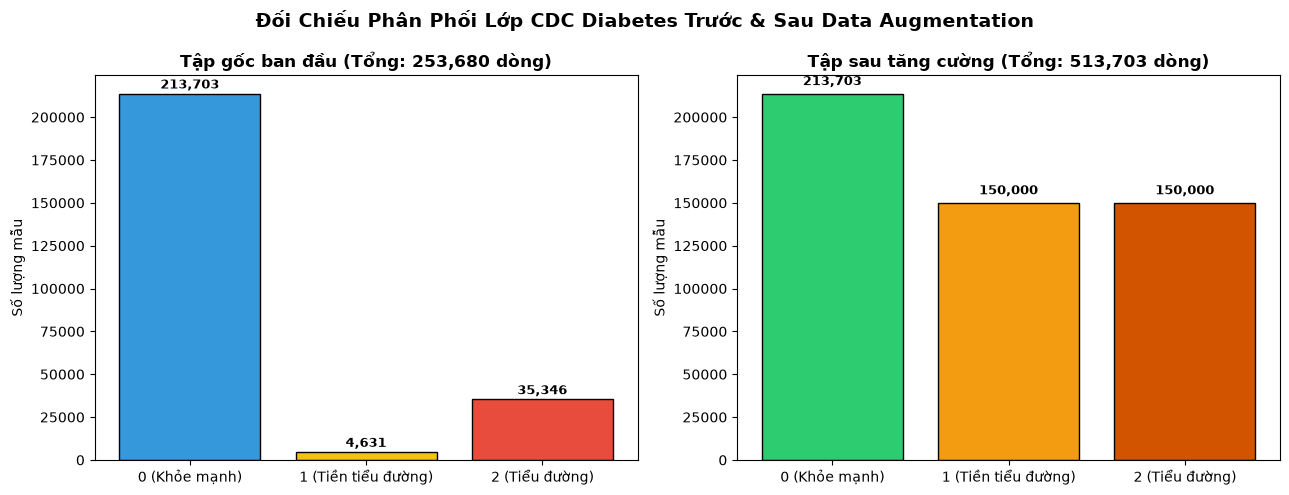

In [8]:
# Cell 8: Biểu đồ đối chiếu phân phối trước và sau Data Augmentation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ['0 (Khỏe mạnh)', '1 (Tiền tiểu đường)', '2 (Tiểu đường)']
c_raw = [dist_raw.get(0.0, 0), dist_raw.get(1.0, 0), dist_raw.get(2.0, 0)]
c_aug = [dist_aug.get(0.0, 0), dist_aug.get(1.0, 0), dist_aug.get(2.0, 0)]

b1 = axes[0].bar(labels, c_raw, color=['#3498db', '#f1c40f', '#e74c3c'], edgecolor='black')
axes[0].set_title(f'Tập gốc ban đầu (Tổng: {len(df_raw):,} dòng)', fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu')
for b in b1:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 3000, f'{int(b.get_height()):,}', ha='center', fontweight='bold', fontsize=9)

b2 = axes[1].bar(labels, c_aug, color=['#2ecc71', '#f39c12', '#d35400'], edgecolor='black')
axes[1].set_title(f'Tập sau tăng cường (Tổng: {len(df_aug):,} dòng)', fontweight='bold')
axes[1].set_ylabel('Số lượng mẫu')
for b in b2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5000, f'{int(b.get_height()):,}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Đối Chiếu Phân Phối Lớp CDC Diabetes Trước & Sau Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()